In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [5]:
df_raw = pd.read_csv('/content/Course_Completion_Prediction.csv')

In [3]:
df_raw.head(10)

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,1/6/2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed
5,STU100005,Rohan Reddy,Female,21,Bachelor,Student,Jaipur,Mobile,Medium,C102,...,23-10-2023,UPI,Yes,No,4526,74,5,2,4.5,Completed
6,STU100006,Sai Nair,Male,22,Diploma,Employed,Chennai,Laptop,High,C103,...,24-03-2024,UPI,Yes,No,5682,83,2,0,4.8,Completed
7,STU100007,Krishna Desai,Male,23,Master,Employed,Hyderabad,Mobile,Low,C101,...,9/11/2024,NetBanking,Yes,No,4590,68,0,0,5.0,Completed
8,STU100008,Vihaan Joshi,Male,17,Bachelor,Student,Nagpur,Tablet,High,C103,...,13-07-2024,Credit Card,Yes,Yes,5055,78,4,2,4.7,Completed
9,STU100009,Vivaan Nair,Male,32,Bachelor,Student,Kolkata,Laptop,Medium,C104,...,7/11/2024,UPI,Yes,Yes,2951,48,1,2,4.4,Completed


In [6]:
df_raw.shape

(19998, 40)

In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    19998 non-null  object 
 1   Name                          19998 non-null  object 
 2   Gender                        19998 non-null  object 
 3   Age                           19998 non-null  int64  
 4   Education_Level               19998 non-null  object 
 5   Employment_Status             19998 non-null  object 
 6   City                          19998 non-null  object 
 7   Device_Type                   19998 non-null  object 
 8   Internet_Connection_Quality   19998 non-null  object 
 9   Course_ID                     19998 non-null  object 
 10  Course_Name                   19998 non-null  object 
 11  Category                      19998 non-null  object 
 12  Course_Level                  19998 non-null  object 
 13  C

In [8]:
df_raw.columns.tolist()

['Student_ID',
 'Name',
 'Gender',
 'Age',
 'Education_Level',
 'Employment_Status',
 'City',
 'Device_Type',
 'Internet_Connection_Quality',
 'Course_ID',
 'Course_Name',
 'Category',
 'Course_Level',
 'Course_Duration_Days',
 'Instructor_Rating',
 'Login_Frequency',
 'Average_Session_Duration_Min',
 'Video_Completion_Rate',
 'Discussion_Participation',
 'Time_Spent_Hours',
 'Days_Since_Last_Login',
 'Notifications_Checked',
 'Peer_Interaction_Score',
 'Assignments_Submitted',
 'Assignments_Missed',
 'Quiz_Attempts',
 'Quiz_Score_Avg',
 'Project_Grade',
 'Progress_Percentage',
 'Rewatch_Count',
 'Enrollment_Date',
 'Payment_Mode',
 'Fee_Paid',
 'Discount_Used',
 'Payment_Amount',
 'App_Usage_Percentage',
 'Reminder_Emails_Clicked',
 'Support_Tickets_Raised',
 'Satisfaction_Rating',
 'Completed']

In [9]:
df_raw.describe()

,Age,Course_Duration_Days,Instructor_Rating,Login_Frequency,Average_Session_Duration_Min,Video_Completion_Rate,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Notifications_Checked,...,Quiz_Attempts,Quiz_Score_Avg,Project_Grade,Progress_Percentage,Rewatch_Count,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating
count,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,...,19998.000000,19998.000000,19998.000000,19998.00000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000
mean,25.707871,51.839184,4.442629,4.784978,33.838384,62.354865,2.338784,3.866502,6.190469,5.239424,...,3.767077,73.107181,68.162071,53.84923,2.325983,3290.710421,68.074457,2.342984,0.875338,4.136254
std,5.593824,20.446404,0.202792,1.837329,10.413292,19.557095,1.599209,3.802413,7.123994,2.387580,...,2.026171,12.579680,15.188416,12.53373,1.589929,2080.192667,19.118735,1.576736,0.951970,0.699692
min,17.000000,25.000000,4.100000,0.000000,5.000000,5.000000,0.000000,0.500000,0.000000,0.000000,...,0.000000,23.500000,6.800000,9.70000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,30.000000,4.300000,3.000000,27.000000,48.800000,1.000000,0.500000,1.000000,4.000000,...,2.000000,64.600000,57.800000,45.40000,1.000000,1369.250000,55.000000,1.000000,0.000000,3.700000
50%,25.000000,45.000000,4.500000,5.000000,34.000000,64.200000,2.000000,2.700000,4.000000,5.000000,...,4.000000,73.200000,68.200000,54.00000,2.000000,3734.000000,68.000000,2.000000,1.000000,4.200000
75%,30.000000,60.000000,4.600000,6.000000,41.000000,77.700000,3.000000,6.300000,9.000000,7.000000,...,5.000000,81.900000,78.700000,62.50000,3.000000,4703.000000,82.000000,3.000000,1.000000,4.800000
max,49.000000,90.000000,4.700000,14.000000,76.000000,99.900000,12.000000,25.600000,99.000000,18.000000,...,15.000000,100.000000,100.000000,97.40000,12.000000,7149.000000,100.000000,13.000000,7.000000,5.000000


In [10]:
df_raw.describe(include="object")

,Student_ID,Name,Gender,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,Course_Level,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Completed
count,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998,19998
unique,19998,300,3,5,4,15,3,3,8,8,5,3,721,6,2,2,2
top,STU119997,Nikhil Desai,Female,Bachelor,Student,Surat,Mobile,Medium,C101,Python Basics,Programming,Beginner,24-01-2024,UPI,Yes,No,Not Completed
freq,1,94,10098,11003,9013,1384,11998,10003,3355,3355,11174,10156,42,6029,14170,16135,10184


In [11]:
# 3. Removing Duplicates
df_clean = df_raw.copy()

print("\nDuplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)




Duplicate rows: 0
Shape after removing duplicates: (19998, 40)


In [12]:
#Target column fix safely
df_clean["Completed"] = df_clean["Completed"].astype(str).str.strip()
print("\nTarget values before encoding:")
print(df_clean["Completed"].value_counts(dropna=False))

target_map = {
    "Completed": 1,
    "Not Completed": 0
}

df_clean["Completed"] = df_clean["Completed"].map(target_map)

print("\nTarget values after encoding:")
print(df_clean["Completed"].value_counts(dropna=False))





Target values before encoding:
Completed
Not Completed    10184
Completed         9814
Name: count, dtype: int64

Target values after encoding:
Completed
0    10184
1     9814
Name: count, dtype: int64


In [13]:
# Checking Missing Values
print(df_clean.isnull().sum().sum())


0


In [14]:
# Dropping Unnecessary Columns


columns_to_drop = [
    "Student_ID",
    "Name",
    "Course_ID",
    "Enrollment_Date"
]

df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

print("\nShape after dropping unnecessary columns:", df_clean.shape)





Shape after dropping unnecessary columns: (19998, 36)


In [15]:
# Storing Data Before Outlier Removal
df_before_outliers = df_clean.copy()

print("\nTarget distribution before outlier removal:")
print(df_before_outliers["Completed"].value_counts())
print(df_before_outliers["Completed"].value_counts(normalize=True) * 100)




Target distribution before outlier removal:
Completed
0    10184
1     9814
Name: count, dtype: int64
Completed
0    50.925093
1    49.074907
Name: proportion, dtype: float64


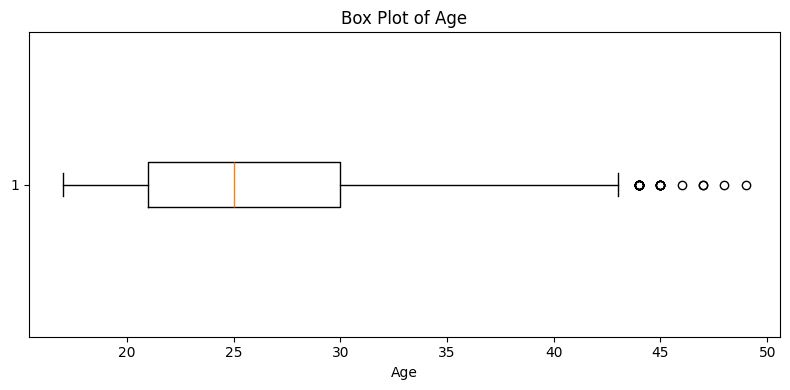

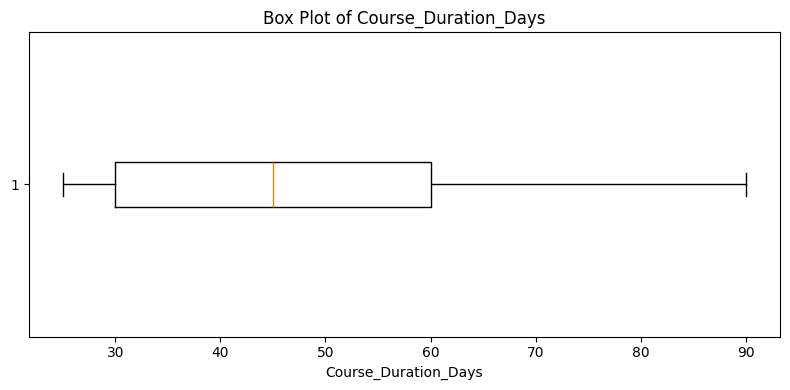

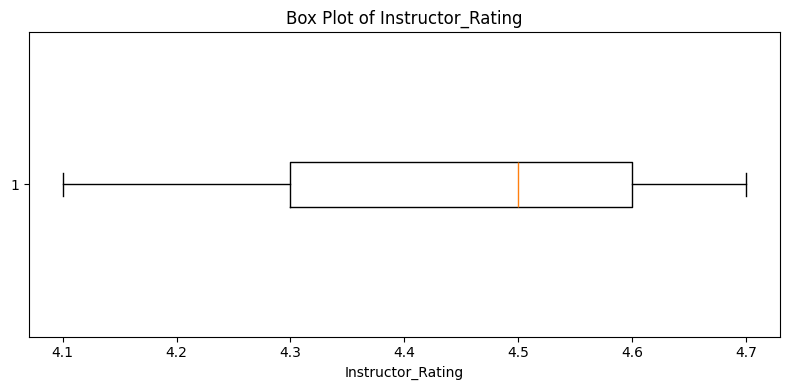

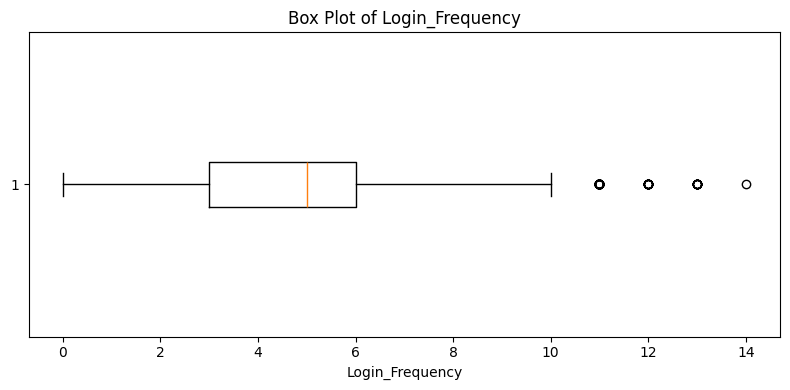

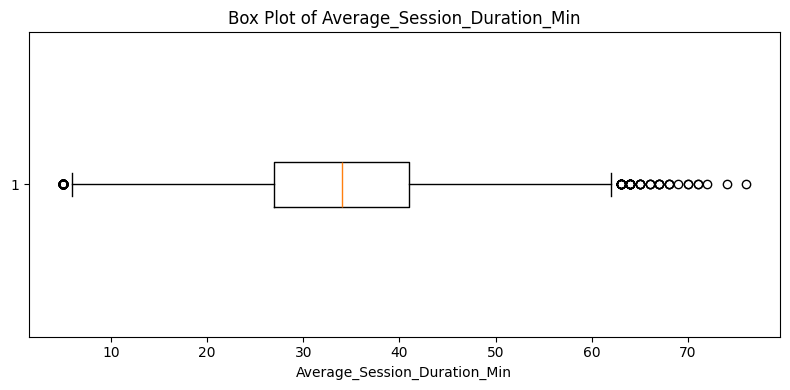

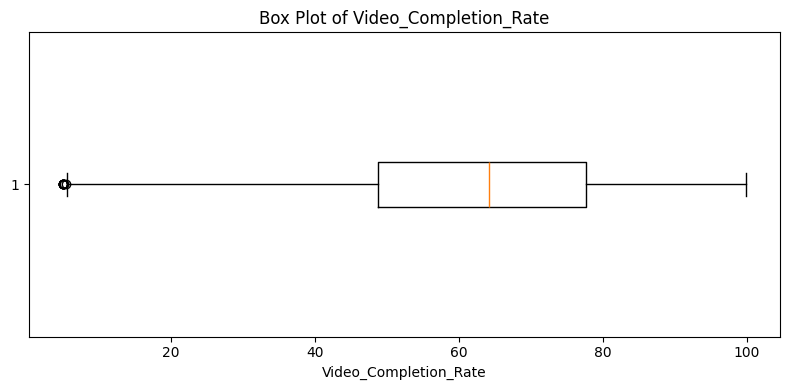

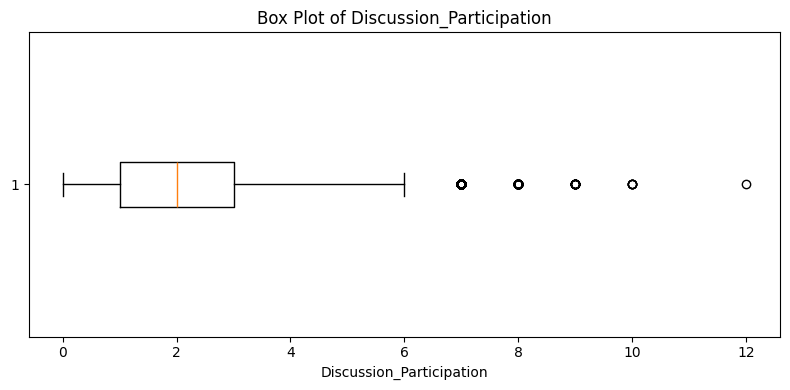

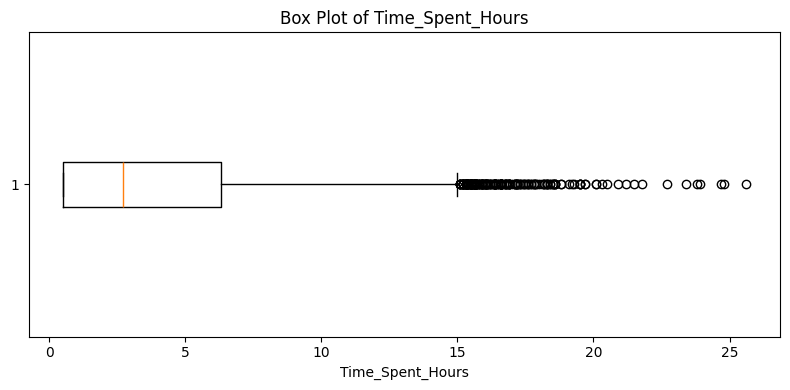

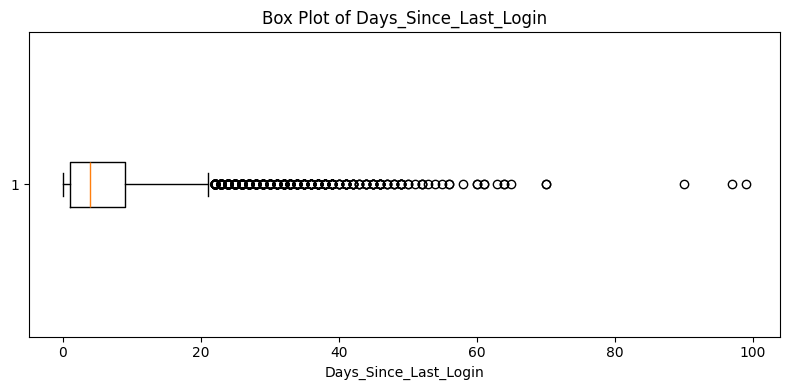

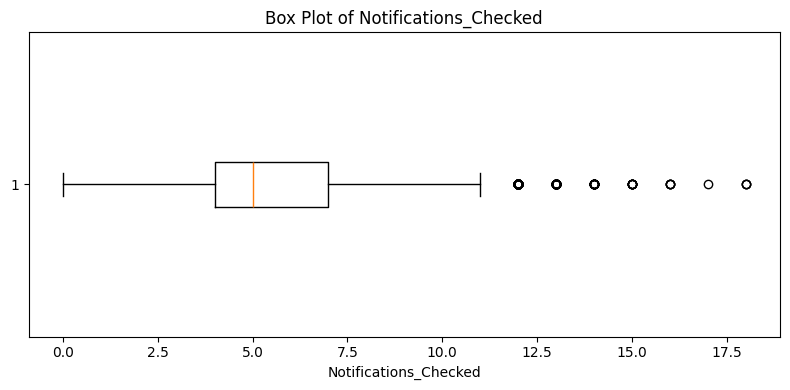

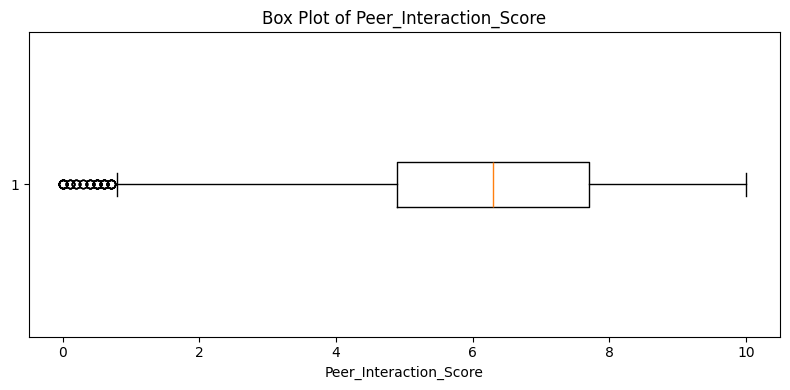

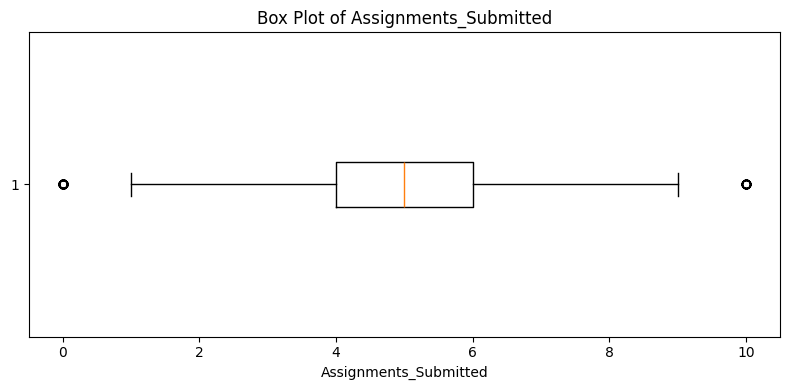

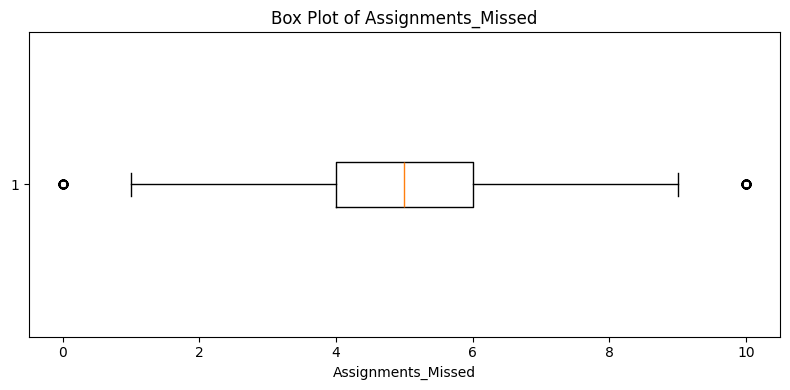

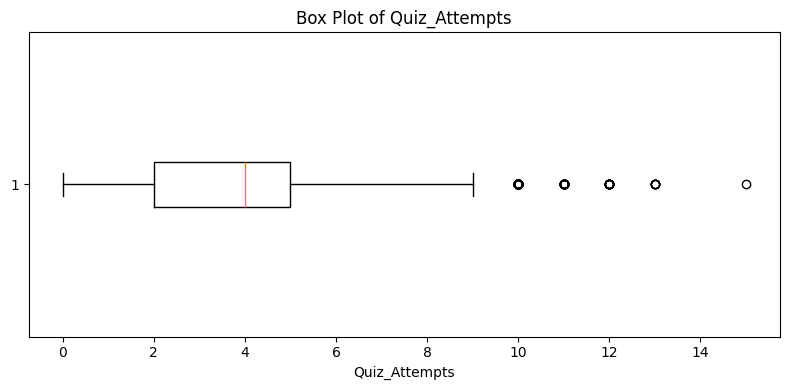

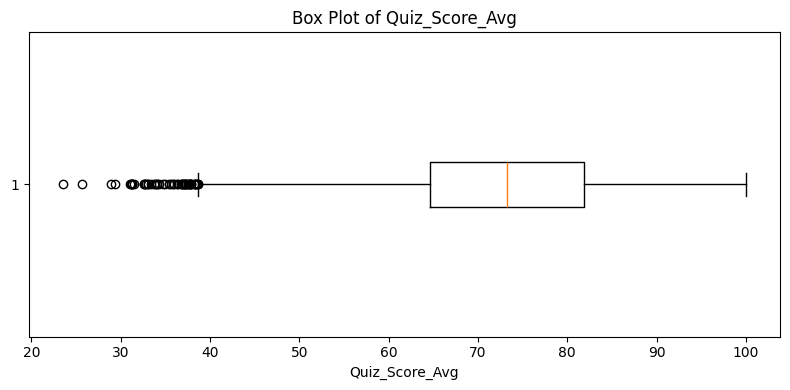

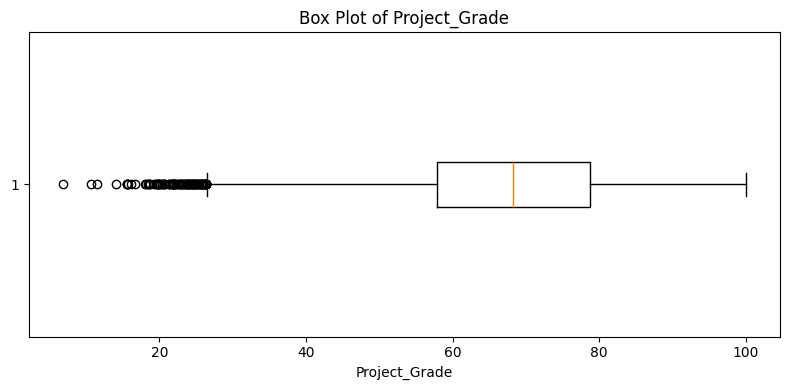

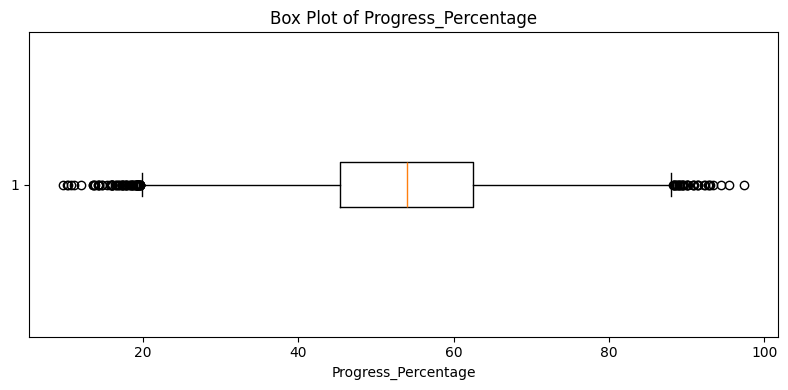

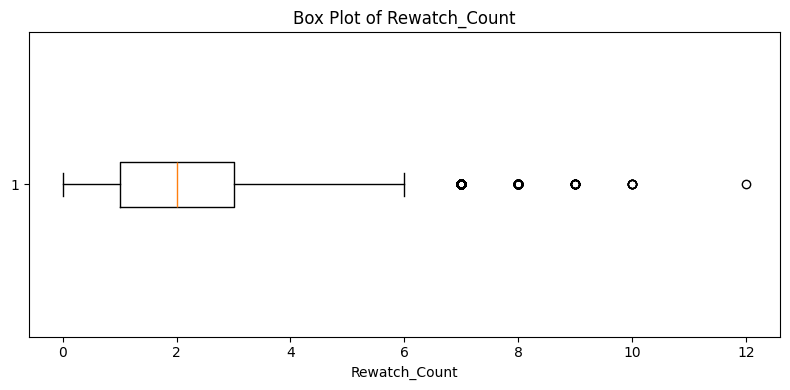

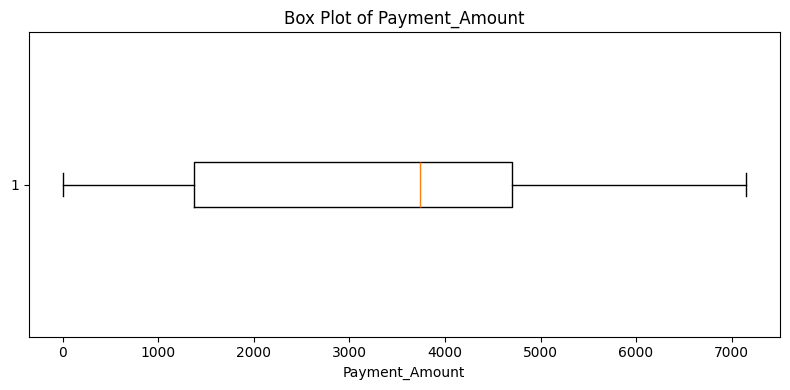

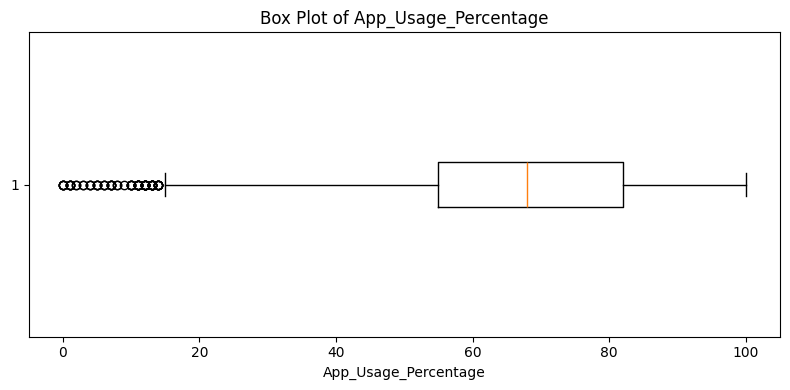

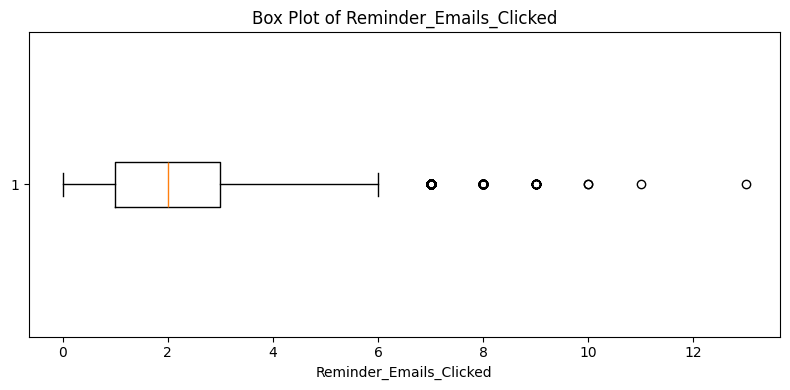

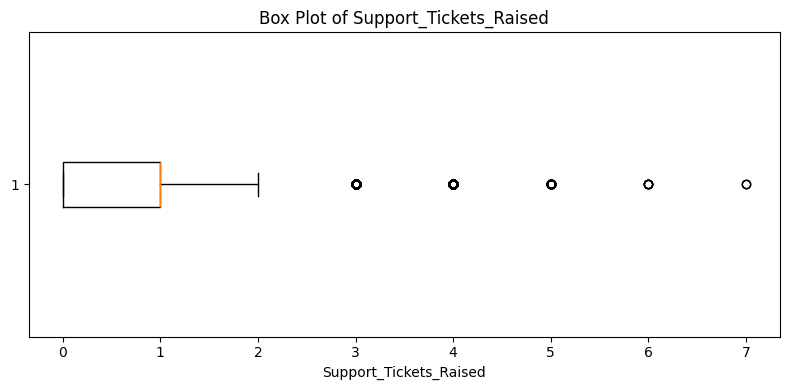

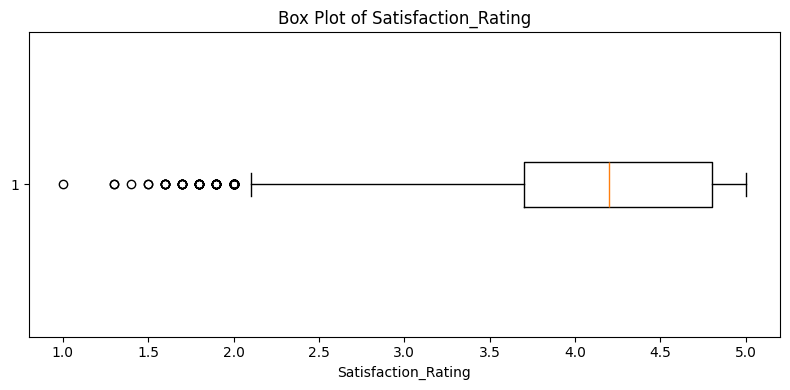

In [18]:

#box plot
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns
numeric_columns_for_outliers = numeric_columns.drop("Completed", errors="ignore")
for col in numeric_columns_for_outliers:

    plt.figure(figsize=(8, 4))

    plt.boxplot(df_clean[col].dropna(), vert=False)

    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [19]:
#Detecting and Remove Outliers Using IQR
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns
numeric_columns_for_outliers = numeric_columns.drop("Completed", errors="ignore")

outlier_mask = pd.Series(False, index=df_clean.index)
outlier_summary = []

for col in numeric_columns_for_outliers:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    column_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_mask = outlier_mask | column_outliers

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": int(column_outliers.sum()),
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

print("\nOutlier summary:")
print(outlier_summary_df.sort_values(by="Outlier Count", ascending=False))

rows_before = df_clean.shape[0]
df_after_outliers = df_clean.loc[~outlier_mask].copy()
rows_after = df_after_outliers.shape[0]

print("\nRows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_before - rows_after)

print("\nTarget distribution after outlier removal:")
print(df_after_outliers["Completed"].value_counts())
print(df_after_outliers["Completed"].value_counts(normalize=True) * 100)



Outlier summary:
                         Feature  Outlier Count  Lower Bound  Upper Bound
21        Support_Tickets_Raised           1241       -1.500        2.500
8          Days_Since_Last_Login            816      -11.000       21.000
6       Discussion_Participation            296       -2.000        6.000
17                 Rewatch_Count            293       -2.000        6.000
20       Reminder_Emails_Clicked            244       -2.000        6.000
9          Notifications_Checked            223       -0.500       11.500
7               Time_Spent_Hours            204       -8.200       15.000
13                 Quiz_Attempts            146       -2.500        9.500
4   Average_Session_Duration_Min            133        6.000       62.000
16           Progress_Percentage            104       19.750       88.150
15                 Project_Grade             90       26.450      110.050
12            Assignments_Missed             83        1.000        9.000
11         Assignmen

In [20]:
# Feature Engineering
df_after_outliers["Learning_Rate"] = (
    df_after_outliers["Progress_Percentage"]
    / df_after_outliers["Course_Duration_Days"]
)

df_after_outliers["Performance_Score"] = (
    df_after_outliers["Quiz_Score_Avg"] * 0.35
    + df_after_outliers["Project_Grade"] * 0.30
    + df_after_outliers["Progress_Percentage"] * 0.25
    + df_after_outliers["Assignments_Submitted"] * 1.00
)

df_after_outliers["Risk_Score"] = (
    df_after_outliers["Assignments_Missed"] * 2.00
    + df_after_outliers["Days_Since_Last_Login"] * 1.50
    - df_after_outliers["Progress_Percentage"] * 0.20
    - df_after_outliers["Video_Completion_Rate"] * 0.15
    - df_after_outliers["Quiz_Score_Avg"] * 0.10
)

df_after_outliers["Risk_Zone"] = pd.qcut(
    df_after_outliers["Risk_Score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)





Rows available for EDA plots: 16126
Target values used in EDA plots:
Completed
0    8150
1    7976
Name: count, dtype: int64


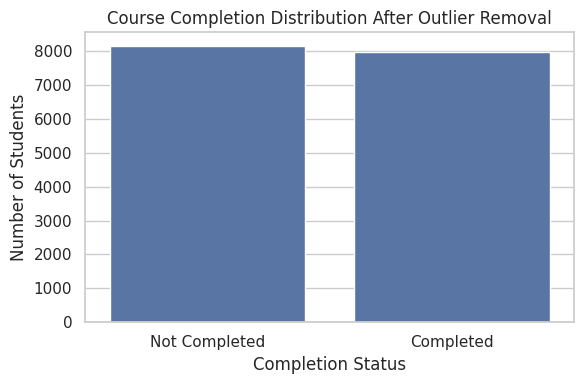

In [21]:
# EDA Plots
sns.set(style="whitegrid")

df_eda = df_after_outliers.copy()

print("\nRows available for EDA plots:", df_eda.shape[0])
print("Target values used in EDA plots:")
print(df_eda["Completed"].value_counts(dropna=False))


# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_eda,
    x="Completed",
    order=[0, 1]
)
plt.title("Course Completion Distribution After Outlier Removal")
plt.xlabel("Completion Status")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["Not Completed", "Completed"])
plt.tight_layout()
plt.show()



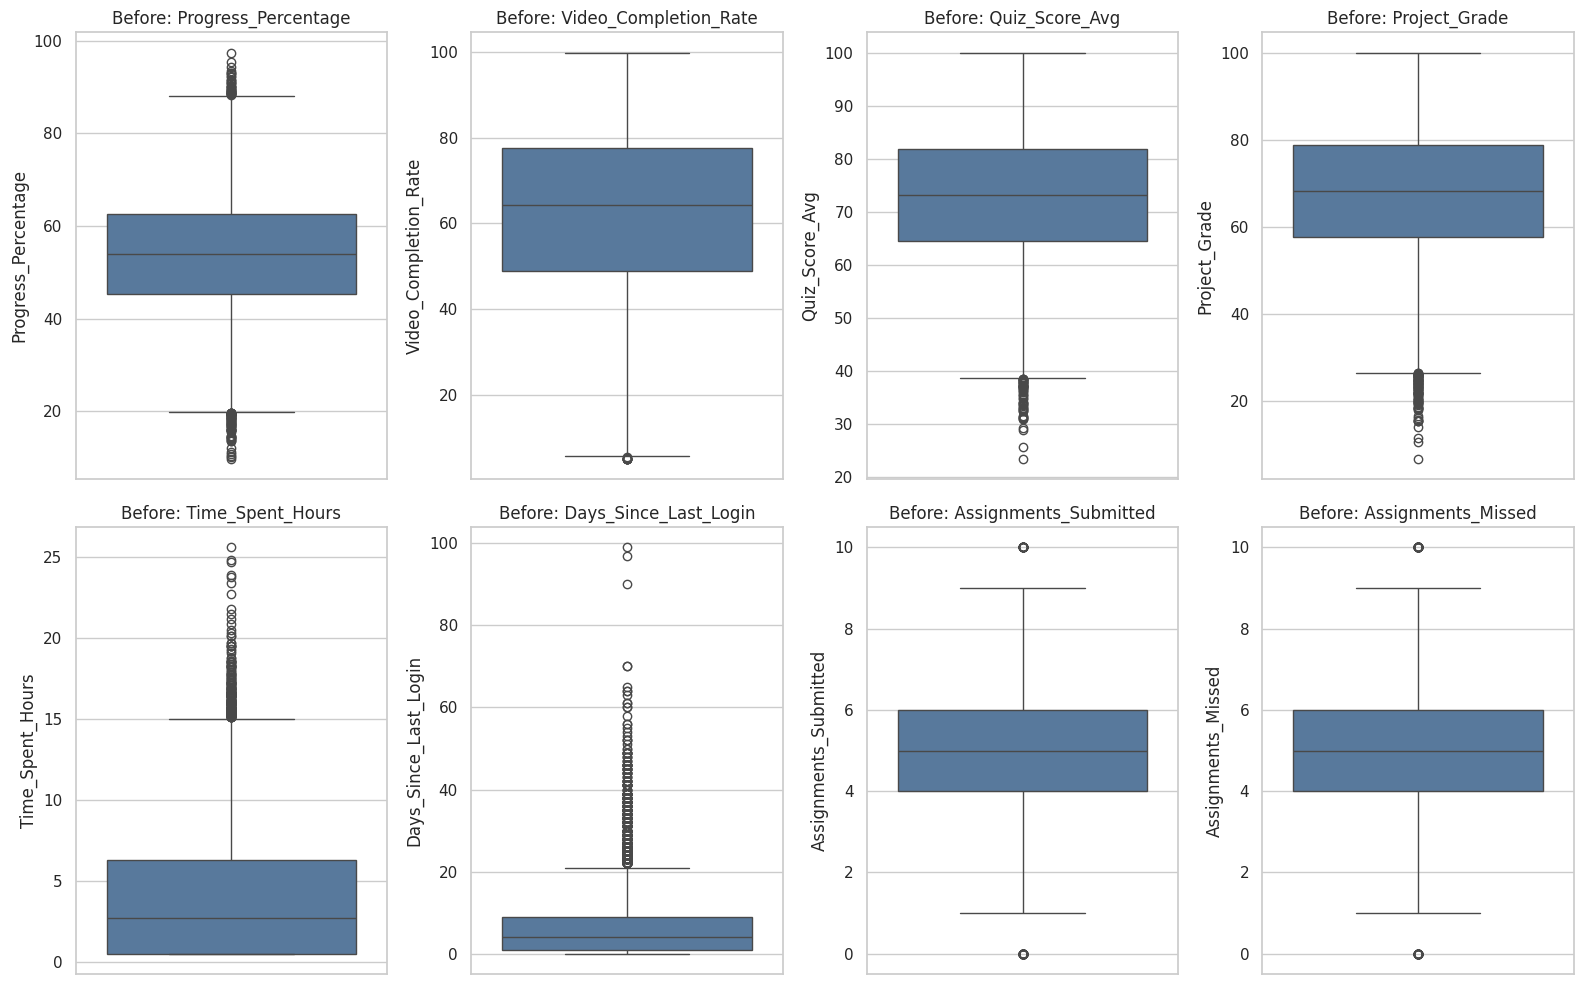

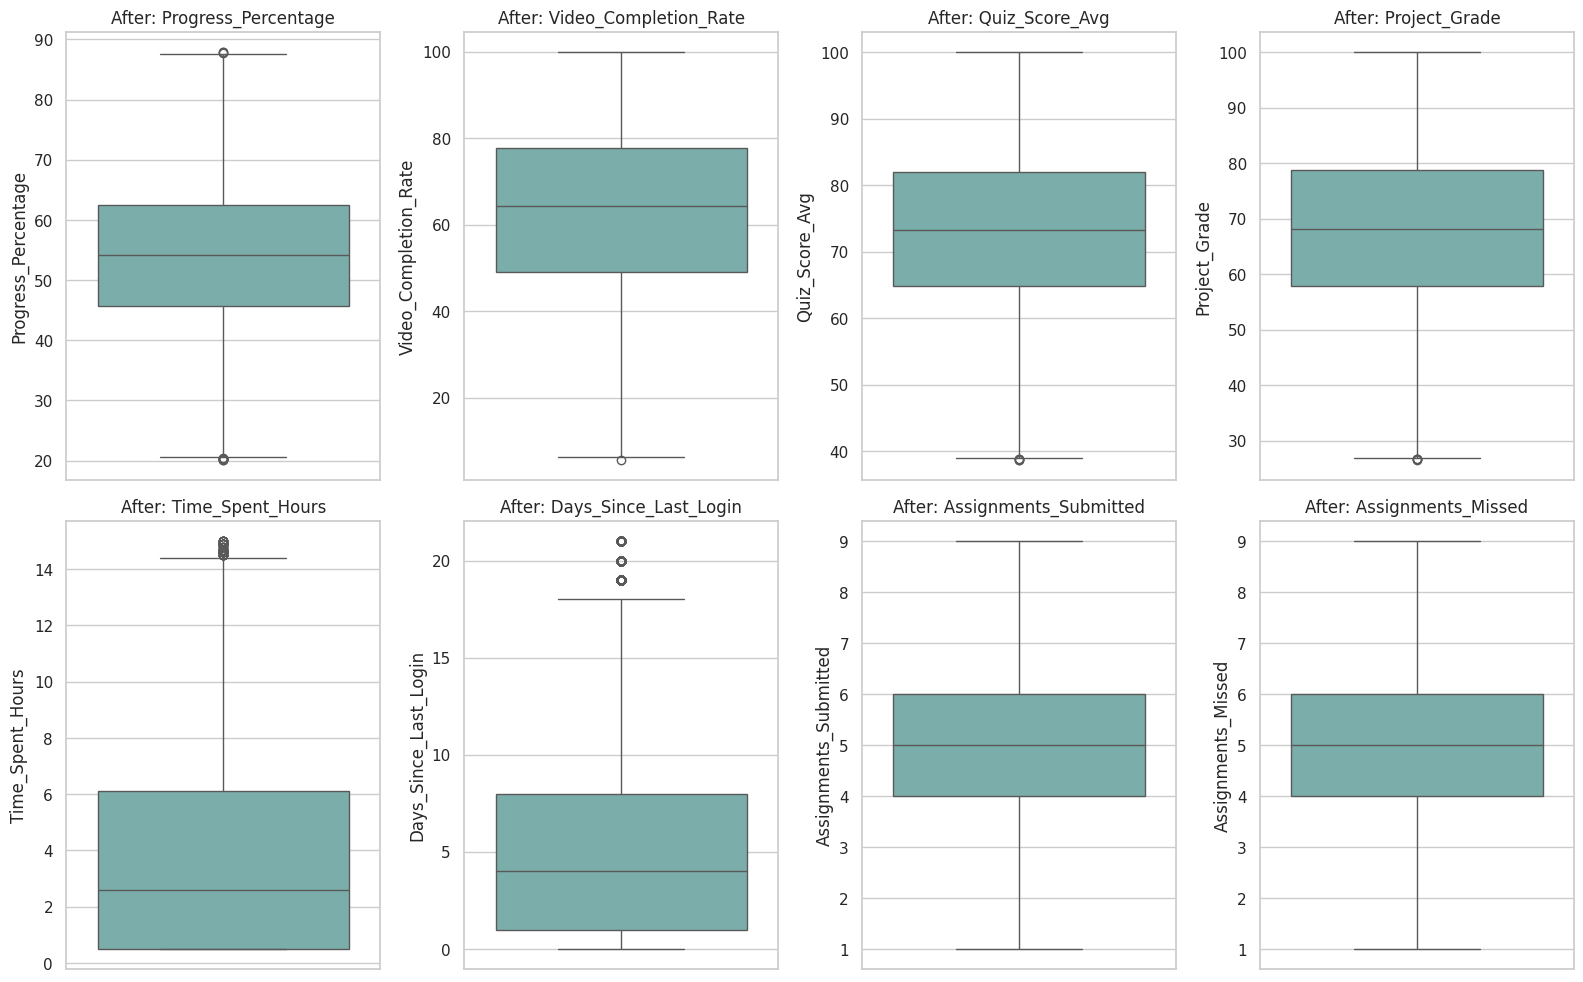

In [22]:
# Boxplots before and after outlier removal
boxplot_features = [
    "Progress_Percentage",
    "Video_Completion_Rate",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Assignments_Submitted",
    "Assignments_Missed"
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(boxplot_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_before_outliers[col], color="#4C78A8")
    plt.title(f"Before: {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 10))
for i, col in enumerate(boxplot_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_eda[col], color="#72B7B2")
    plt.title(f"After: {col}")
plt.tight_layout()
plt.show()

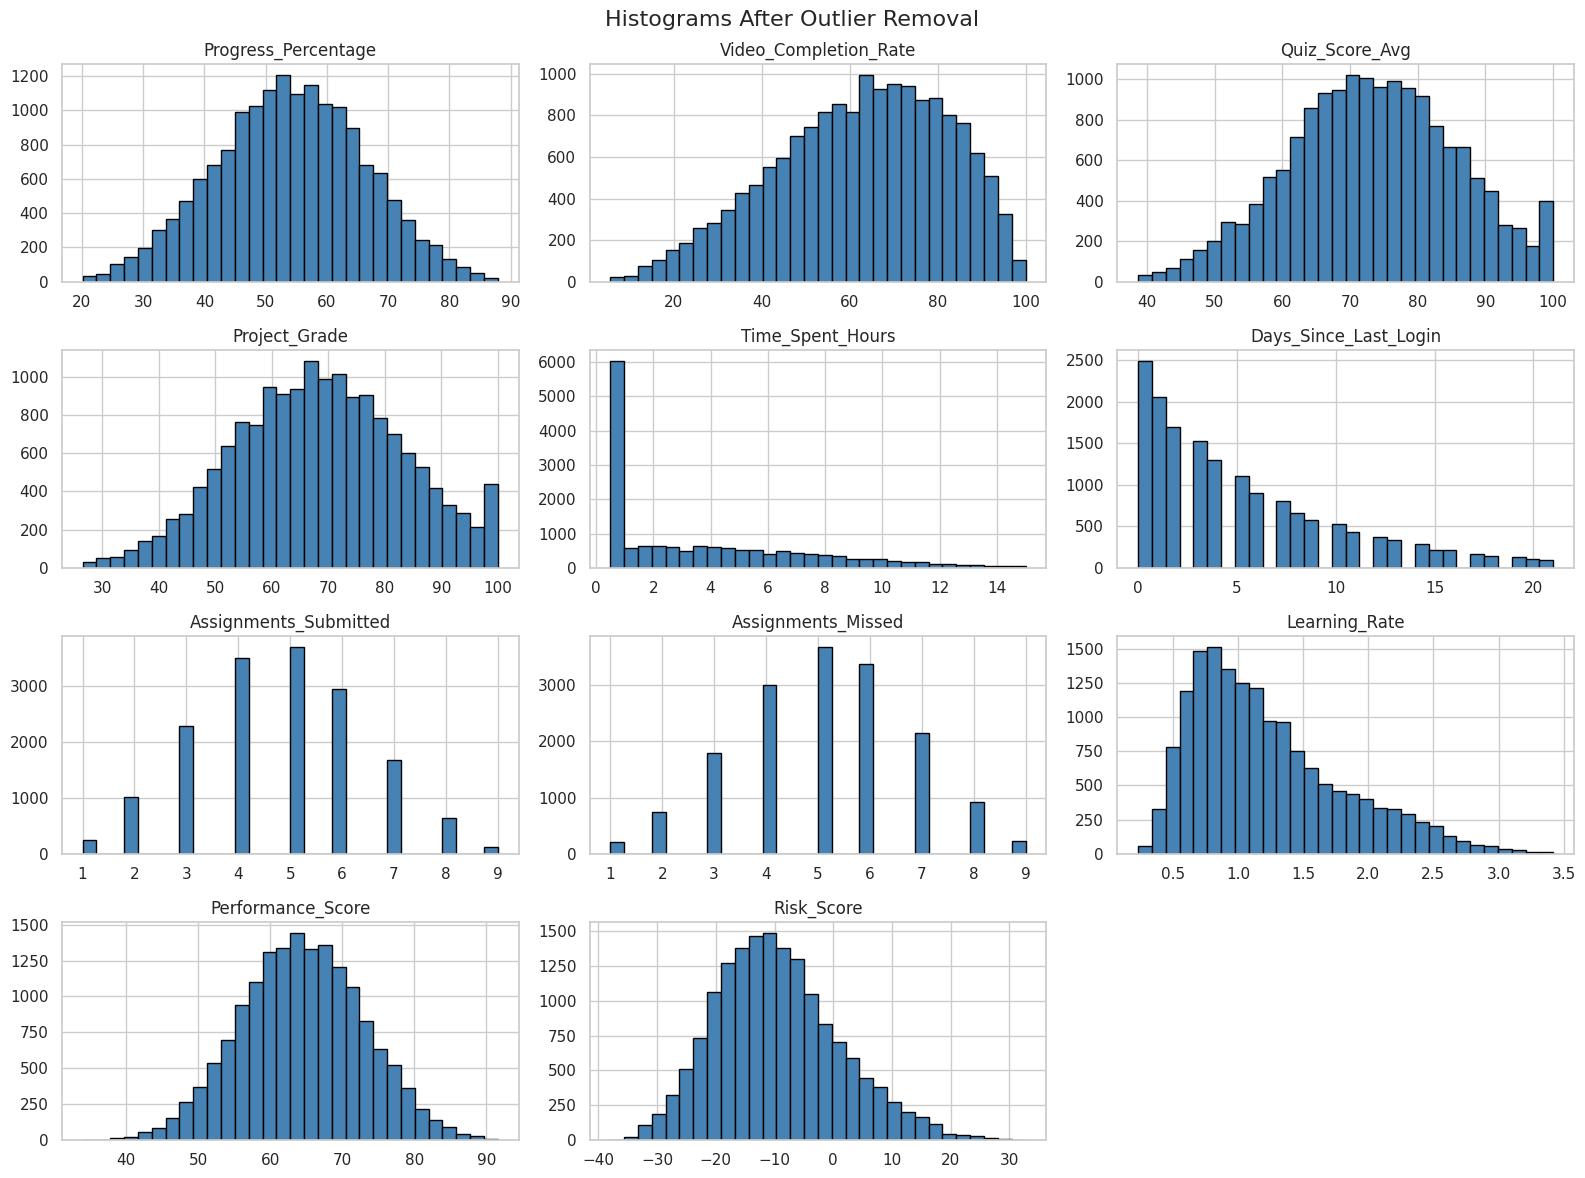

In [23]:
# Histograms
histogram_features = [
    "Progress_Percentage",
    "Video_Completion_Rate",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Learning_Rate",
    "Performance_Score",
    "Risk_Score"
]

df_eda[histogram_features].hist(
    bins=30,
    figsize=(16, 12),
    color="steelblue",
    edgecolor="black"
)
plt.suptitle("Histograms After Outlier Removal", fontsize=16)
plt.tight_layout()
plt.show()



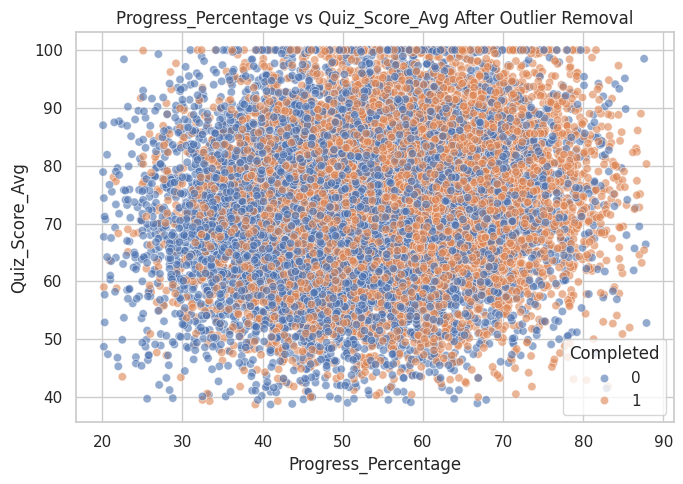

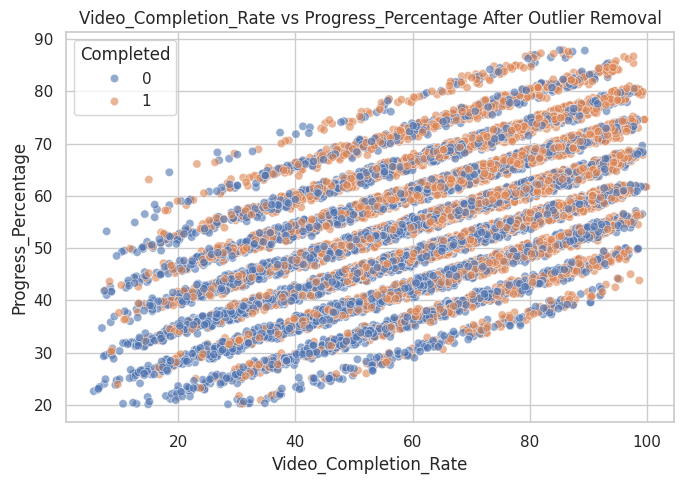

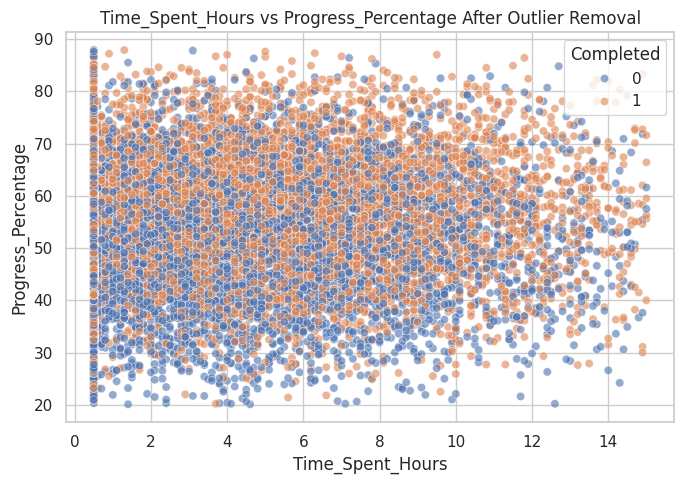

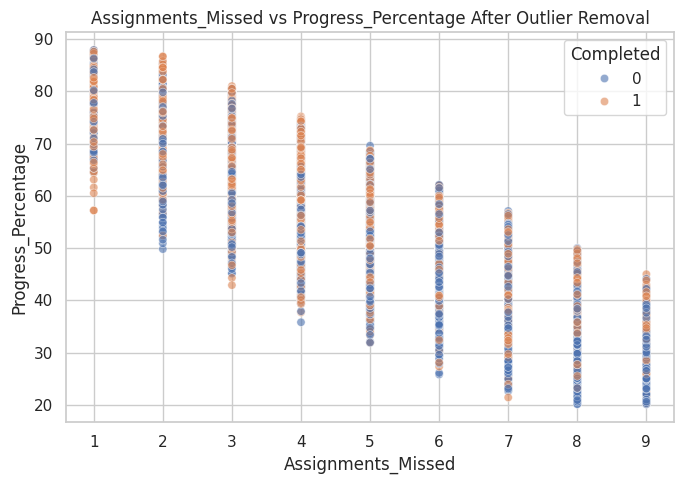

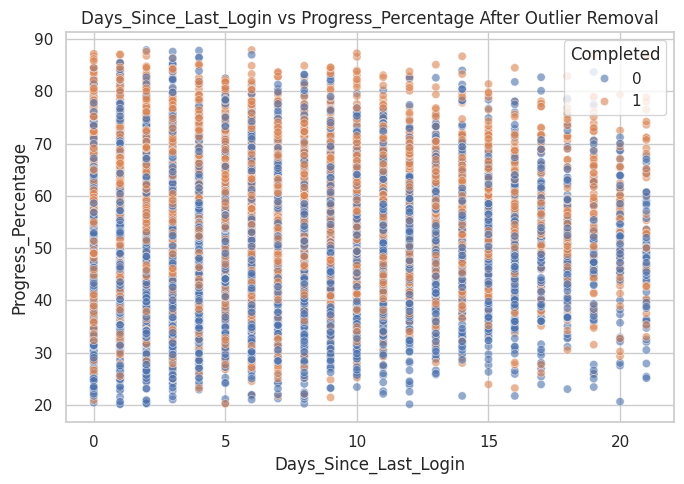

In [24]:
# Scatter plots
scatter_pairs = [
    ("Progress_Percentage", "Quiz_Score_Avg"),
    ("Video_Completion_Rate", "Progress_Percentage"),
    ("Time_Spent_Hours", "Progress_Percentage"),
    ("Assignments_Missed", "Progress_Percentage"),
    ("Days_Since_Last_Login", "Progress_Percentage")
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df_eda,
        x=x_col,
        y=y_col,
        hue="Completed",
        hue_order=[0, 1],
        alpha=0.6
    )
    plt.title(f"{x_col} vs {y_col} After Outlier Removal")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


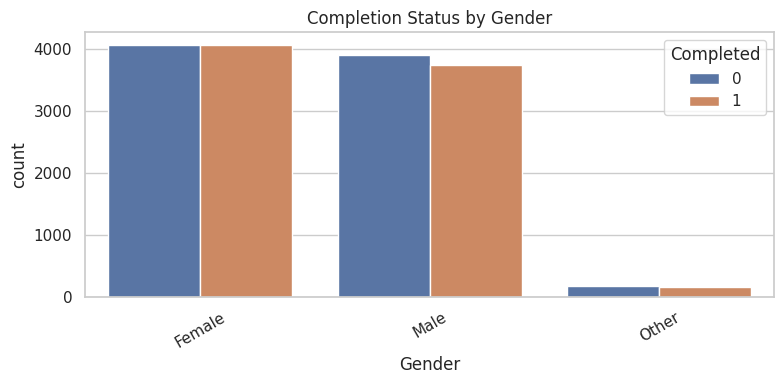

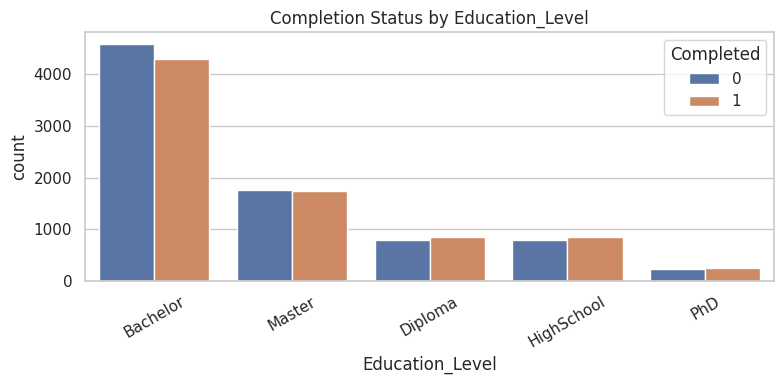

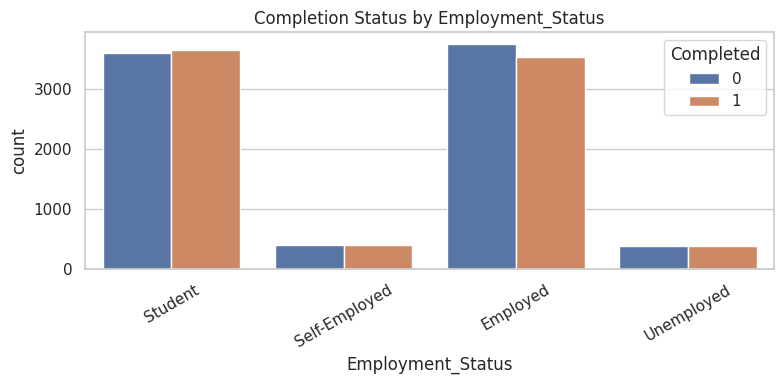

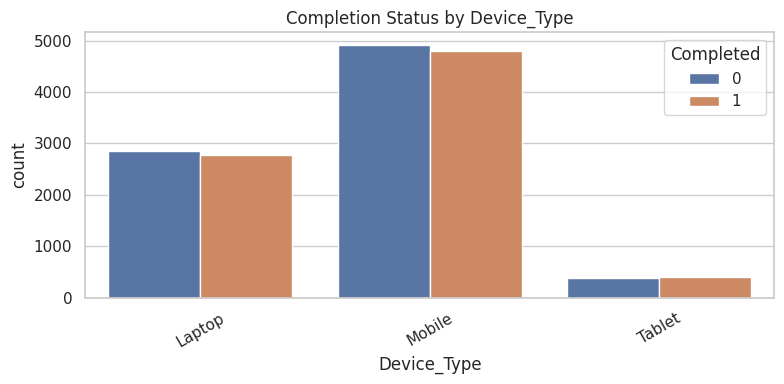

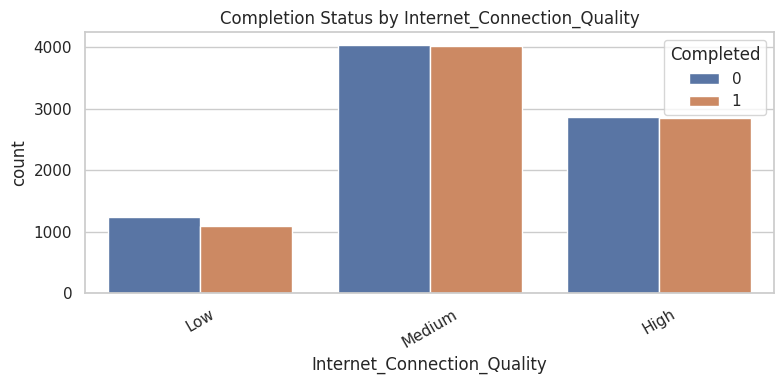

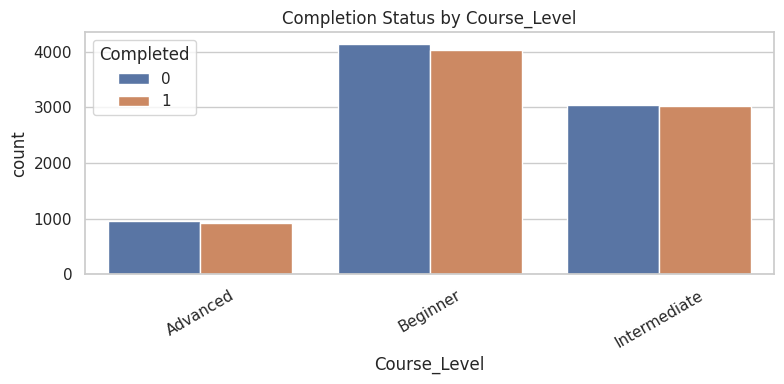

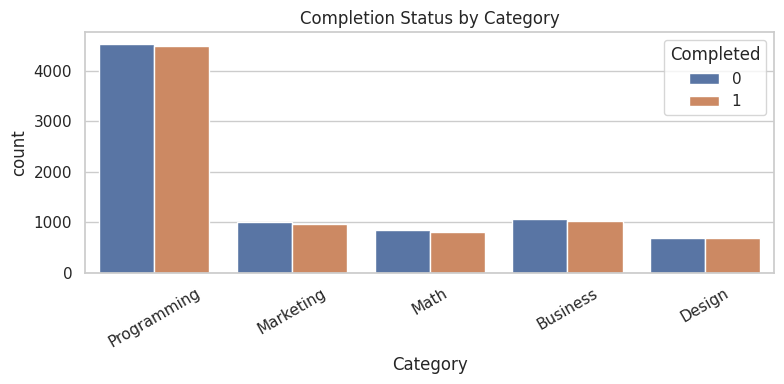

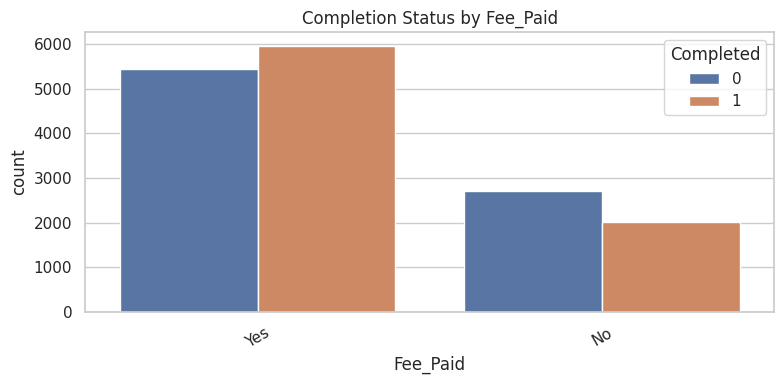

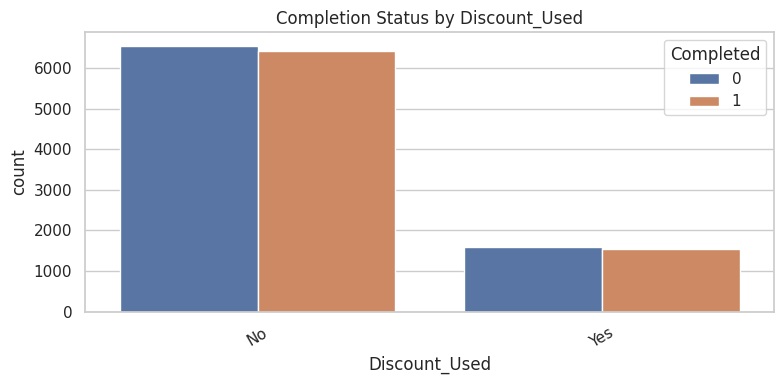

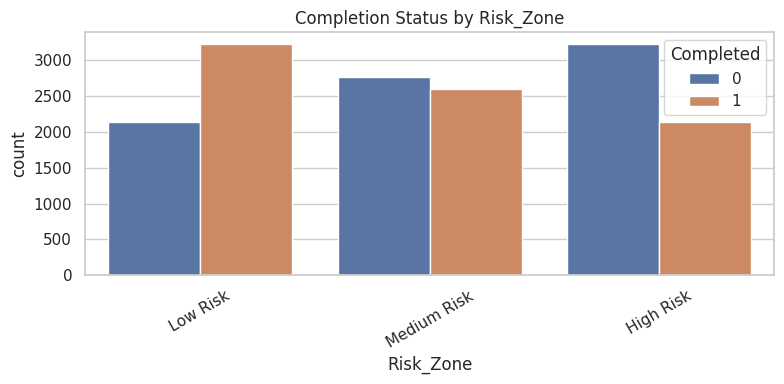


Course-wise completion rate after outlier removal:
                    Course_Name  Completion_Rate
0            Introduction to AI        50.395648
1     Data Analysis with Python        49.958299
2                 Python Basics        49.725174
3     UI/UX Design Fundamentals        49.527273
4   Statistics for Data Science        49.096386
5  Digital Marketing Essentials        49.043303
6            Excel for Business        48.868560
7          Machine Learning A-Z        48.802555


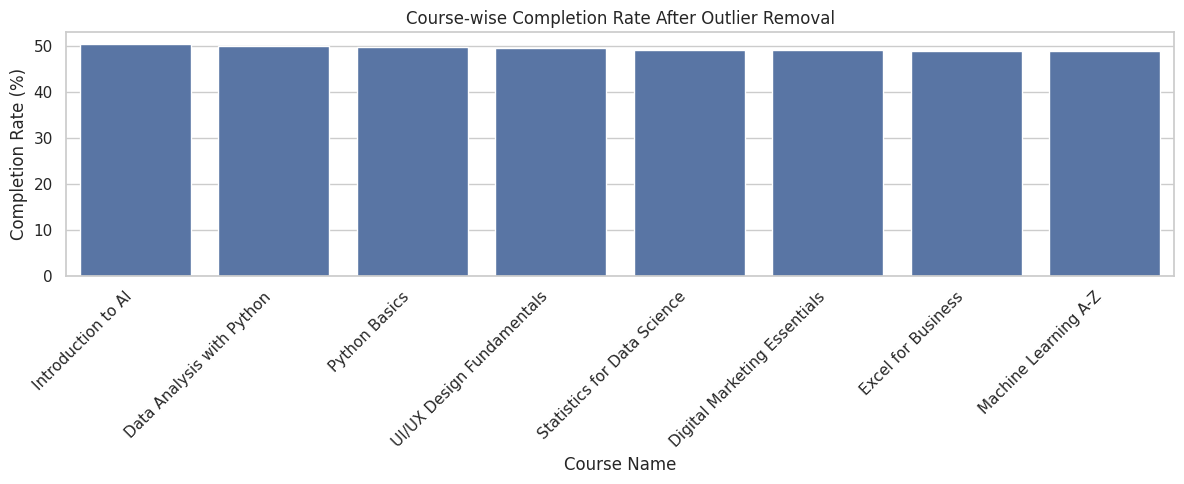

In [25]:
# Categorical analysis
categorical_features = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_Level",
    "Category",
    "Fee_Paid",
    "Discount_Used",
    "Risk_Zone"
]

for col in categorical_features:
    if col in df_eda.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(
            data=df_eda,
            x=col,
            hue="Completed",
            hue_order=[0, 1]
        )
        plt.title(f"Completion Status by {col}")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()


# Course-wise completion rate
if "Course_Name" in df_eda.columns:
    course_completion = (
        df_eda.groupby("Course_Name")["Completed"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    course_completion["Completion_Rate"] = course_completion["Completed"] * 100

    print("\nCourse-wise completion rate after outlier removal:")
    print(course_completion[["Course_Name", "Completion_Rate"]])

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=course_completion,
        x="Course_Name",
        y="Completion_Rate"
    )
    plt.title("Course-wise Completion Rate After Outlier Removal")
    plt.ylabel("Completion Rate (%)")
    plt.xlabel("Course Name")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



In [26]:
# Encoding Categorical Variables
df_encoded = df_eda.copy()
categorical_columns = df_encoded.select_dtypes(include=["object", "category"]).columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("\nCategorical columns encoded for modeling:")
print(list(categorical_columns))


Categorical columns encoded for modeling:
['Gender', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_Name', 'Category', 'Course_Level', 'Payment_Mode', 'Fee_Paid', 'Discount_Used', 'Risk_Zone']


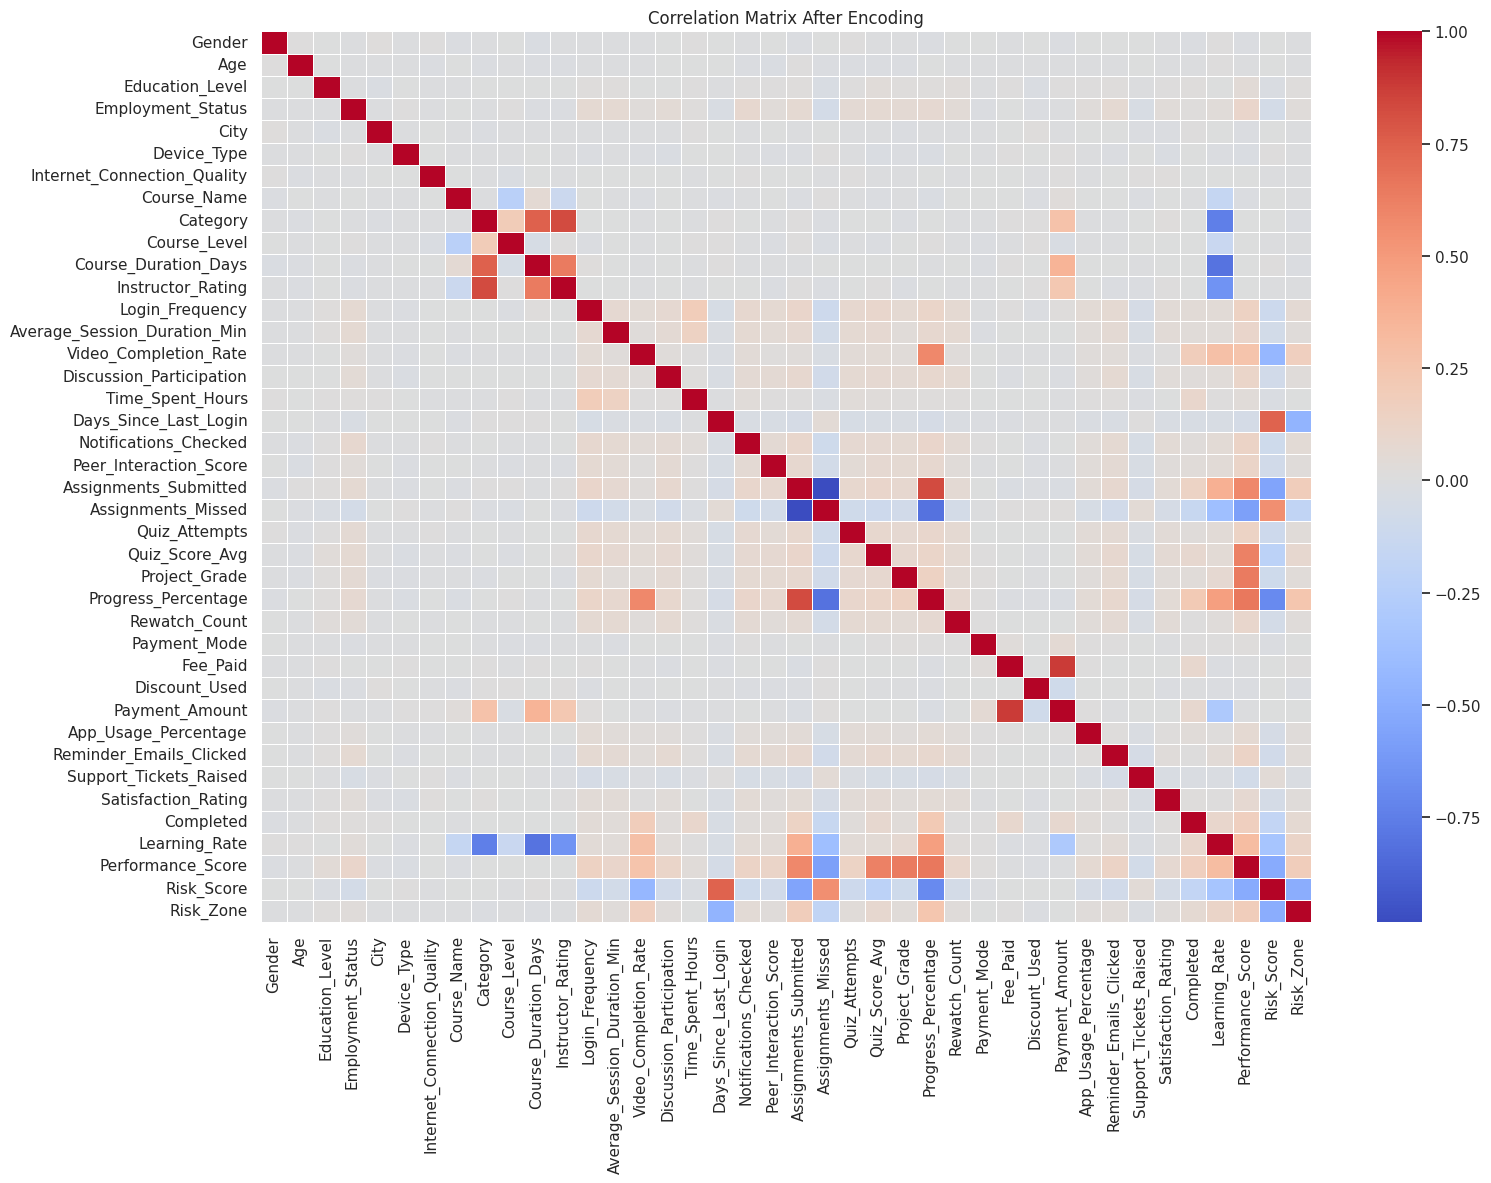


Correlation with Completed target:
Completed                       1.000000
Progress_Percentage             0.217536
Video_Completion_Rate           0.185054
Performance_Score               0.165917
Assignments_Submitted           0.138843
Time_Spent_Hours                0.097479
Learning_Rate                   0.097215
Fee_Paid                        0.087746
Quiz_Score_Avg                  0.082634
Payment_Amount                  0.080091
Risk_Zone                       0.069877
Login_Frequency                 0.039924
App_Usage_Percentage            0.039395
Project_Grade                   0.035303
Average_Session_Duration_Min    0.033438
Peer_Interaction_Score          0.032640
Discussion_Participation        0.028663
Quiz_Attempts                   0.025459
Notifications_Checked           0.025316
Satisfaction_Rating             0.023305
Education_Level                 0.018487
Employment_Status               0.018362
Rewatch_Count                   0.015414
Payment_Mode         

In [27]:
# Correlation Matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Matrix After Encoding")
plt.tight_layout()
plt.show()

print("\nCorrelation with Completed target:")
print(correlation_matrix["Completed"].sort_values(ascending=False))


In [29]:
# Scaling Numerical Features
df_scaled = df_encoded.copy()

numeric_columns = df_scaled.select_dtypes(include=["int64", "float64"]).columns
numeric_columns = numeric_columns.drop("Completed", errors="ignore")

scaler = StandardScaler()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])

print("\nNumerical features scaled for modeling.")





Numerical features scaled for modeling.


In [33]:
import os

print(os.getcwd())

/content


In [34]:
df_scaled.to_csv("processed_dataset.csv", index=False)

print("File saved successfully.")

File saved successfully.
